# Analyse Track: Daten auswerten und Berichte erstellen

### Was bauen wir heute?
1. Daten aus der PostgreSQL direkt in pandas laden
2. Daten bereinigen und auswerten
3. Kennzahlen (KPIs) berechnen
4. Visualisierung im Notebook erstellen
5. Formatierten Excel-Bericht mit Diagramm exportieren
6. Breicht automatisieren
-------

## Block 1: Bibliotheken installieren und Verbindung herstellen

In [1]:
import pandas as pd
import psycopg2
import psycopg2.extras
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Pandas-Ausgabe schöner machen:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

VERBINDUNG = {
    'host' : 'localhost',
    'dbname': 'klinik',
    'user' : 'postgres',
    'password' : '300319',
    'port': 5432
}

# Verbindung testen:
try:
    conn = psycopg2.connect(**VERBINDUNG)
    print(' Verbindung zur Klinik-Datenbank erfolgreich!')
    conn.close()
except Exception as e:
    print(f'   Fehler: {e}')

 Verbindung zur Klinik-Datenbank erfolgreich!


## Block 2: Daten direkt aus PostgreSQL in pandas laden

`pandas.read_sql()` führt eine SQL-Abfrage aus und gibt das Ergebnis direkt als DataFrame zurück. Das ist eine Zeile Code statt `.fetchall()` und Loops.

In [9]:
conn = psycopg2.connect(**VERBINDUNG)

# Patienten laden:

df_patienten  = pd.read_sql(
    '''
    SELECT
        p.id,
        p.vorname,
        p.nachname,
        p.geburtsdatum,
        p.versicherung,
        p.aufgenommen,
        a.name AS arzt,
        a.fachgebiet
    FROM patientendaten.patienten AS p
    LEFT JOIN personal.aerzte AS a ON p.behandelnder_arzt_id = a.id
    ORDER BY p.aufgenommen DESC
    ''',
    conn,
    parse_dates = ['geburtsdatum', 'aufgenommen']
)

# Diagnosen laden:
df_diagnosen = pd.read_sql(
    '''
    SELECT
        d.id,
        d.patient_id,
        d.icd_code,
        d.beschreibung,
        d.vertraulich,
        d.erstellt_am,
        a.name AS arzt,
        a.fachgebiet
    FROM patientendaten.diagnosen AS d
    LEFT JOIN personal.aerzte AS a ON d.arzt_id = a.id
    ORDER BY d.erstellt_am DESC
    ''',
    conn,
    parse_dates = ['erstellt_am']
)

# Medikamente laden
df_medikamente = pd.read_sql(
    '''
    SELECT
        m.id,
        m.patient_id,
        m.bezeichnung,
        m.dosierung,
        m.von_datum,
        m.bis_datum,
        a.name AS arzt
    FROM patientendaten.medikamente AS m
    LEFT JOIN personal.aerzte AS a ON m.arzt_id = a.id
    ''',
    conn,
    parse_dates = ['von_datum', 'bis_datum']
)

conn.close()
print(f' Patienten:      {len(df_patienten)} Zeilen')
print(f' Diagnosen:      {len(df_diagnosen)} Zeilen')
print(f' Medikamente:    {len(df_medikamente)} Zeilen')

 Patienten:      61 Zeilen
 Diagnosen:      164 Zeilen
 Medikamente:    102 Zeilen


In [11]:
# Ersten Blick auf die Daten werfen:
print('=== Patienten (erste 5 Zeilen) ===')
df_patienten.head()

=== Patienten (erste 5 Zeilen) ===


,id,vorname,nachname,geburtsdatum,versicherung,aufgenommen,arzt,fachgebiet
0,63,Max,Mustermann,1985-06-07,Techniker Krankenkasse,2026-04-28 09:28:34.188209,NaN,NaN
1,10,Franz,Schwarz,1951-05-29,Signal Iduna,2025-12-29 00:00:00.000000,Dr. Laura Müller,Neurologie
2,22,Walter,Meyer,1952-09-07,IKK,2025-12-26 00:00:00.000000,Dr. Felix Klein,Chirurgie
3,23,Michael,Huber,1994-04-29,Barmer,2025-12-16 00:00:00.000000,Dr. Sarah Hoffmann,Innere Medizin
4,27,Christian,Weber,1947-10-27,HEK,2025-11-18 00:00:00.000000,Dr. Felix Klein,Chirurgie


In [13]:
# Grundlegende Infos über den DataFrame:

print('Spalten:', list(df_patienten.columns))
print(f'\nDatentypen:')
print(df_patienten.dtypes)
print(f'\nFehlende Werte:')
print(df_patienten.isnull().sum())

Spalten: ['id', 'vorname', 'nachname', 'geburtsdatum', 'versicherung', 'aufgenommen', 'arzt', 'fachgebiet']

Datentypen:
id                       int64
vorname                    str
nachname                   str
geburtsdatum     datetime64[s]
versicherung               str
aufgenommen     datetime64[us]
arzt                       str
fachgebiet                 str
dtype: object

Fehlende Werte:
id              0
vorname         0
nachname        0
geburtsdatum    0
versicherung    0
aufgenommen     0
arzt            1
fachgebiet      1
dtype: int64


--------

## Block 3: Daten bereinigen und anreichern

Rohdaten aus Datenbanken sind seltenst sofort auswertbar. Wir berechnen nun erstmal neue Spalten und bereinigen fehlende Werte.

In [20]:
import numpy as np
from datetime import date

#Alter Berechnen:
heute = pd.Timestamp(date.today())
df_patienten['alter'] = (
    (heute - df_patienten['geburtsdatum']).dt.days / 365.25
).astype(int)

#Altersgruppen kategorisieren:
df_patienten['altersgruppe'] = pd.cut(
    df_patienten['alter'],
    bins = [0, 30, 50, 65, 120],
    labels = ['Unter 30', '30-50', '51-65', 'Über 65']
)

# Aufnahme-Monat extrahieren:
df_patienten['aufnahme_monat'] = df_patienten['aufgenommen'].dt.to_period('M')

# Fehlende Versicherung mit "Unbekannt" füllen:
df_patienten['versicherung'] = df_patienten['versicherung'].fillna('Unbekannt')

print('Neue Spalten hinzugefügt: alter, altersgruppe, aufnahme_monat')
df_patienten[['vorname', 'nachname', 'alter', 'altersgruppe', 'versicherung', 'aufnahme_monat']].head(8)

Neue Spalten hinzugefügt: alter, altersgruppe, aufnahme_monat


,vorname,nachname,alter,altersgruppe,versicherung,aufnahme_monat
0,Max,Mustermann,40,30-50,Techniker Krankenkasse,2026-04
1,Franz,Schwarz,74,Über 65,Signal Iduna,2025-12
2,Walter,Meyer,73,Über 65,IKK,2025-12
3,Michael,Huber,32,30-50,Barmer,2025-12
4,Christian,Weber,78,Über 65,HEK,2025-11
5,Wolfgang,Mayer,62,51-65,Privat GmbH,2025-08
6,Daniel,Hartmann,27,Unter 30,BKK,2025-07
7,Walter,Krüger,62,51-65,IKK,2025-07


-------

## Block 4: Auswertung und KPIs

Jetzt rechnen wir mal. pandas macht das mit einer Zeile Code.

In [22]:
# KPI 1: Patienten nach Versicherung
print('=== Patienten nach Versicherung ===')
versicherung_stats = (
    df_patienten['versicherung']
        .value_counts()
        .reset_index()
)
versicherung_stats.columns = ['versicherung', 'anzahl']
versicherung_stats['anteil_pct'] = (
    versicherung_stats['anzahl'] / len(df_patienten) * 100
).round(1)
print(versicherung_stats.to_string(index=False))

=== Patienten nach Versicherung ===
          versicherung  anzahl  anteil_pct
                   BKK      11       18.00
            AOK Bayern       8       13.10
                   IKK       7       11.50
                Barmer       7       11.50
                   KKH       6        9.80
                   DAK       6        9.80
           Privat GmbH       5        8.20
                   HEK       4        6.60
          Signal Iduna       3        4.90
                    TK       3        4.90
Techniker Krankenkasse       1        1.60


In [24]:
# KPI 2: Patienten nach Altersgruppe:
print('=== Altersverteilung ===')
alter_stats = df_patienten['altersgruppe'].value_counts().sort_index()
print(alter_stats)
print(f'\nDurchschnittsalter: {df_patienten['alter'].mean():.1f} Jahre')
print(f'Jüngster Patient:    {df_patienten['alter'].min()} Jahre')
print(f'Ältester Patient:     {df_patienten['alter'].max()} Jahre')

=== Altersverteilung ===
altersgruppe
Unter 30     4
30-50       18
51-65       20
Über 65     19
Name: count, dtype: int64

Durchschnittsalter: 55.0 Jahre
Jüngster Patient:    27 Jahre
Ältester Patient:     81 Jahre


In [30]:
# KPI 3: Diagnosen nach ICD_Berecih und Arzt

print('=== Häufigste Diagnosen ===')
diagnosen_stats = (
    df_diagnosen
    .groupby(['icd_code', 'beschreibung'])
    .size()
    .reset_index(name='anzahl')
    .sort_values('anzahl', ascending = False)
    .head(10)
)

print(diagnosen_stats.to_string(index=False))

=== Häufigste Diagnosen ===
icd_code                                          beschreibung  anzahl
   I21.0                 Akuter transmuraler Vorderwandinfarkt      13
   J18.0 Lobärpneumonie durch nicht näher bezeichneten Erreger      12
     G35                                     Multiple Sklerose      11
   C34.1            Bösartige Neubildung des Lungenoberlappens      11
   G43.0                                     Migräne ohne Aura      11
   M51.1                Lumbale und andere Bandscheibenschäden      10
   K40.2             Bilaterale Leistenhernie ohne Obstruktion      10
   Z51.1                                 Chemotherapie-Sitzung      10
   N20.0                                           Nierenstein       9
   J44.1                          COPD mit akuter Exazerbation       9


In [32]:
#KPI 4: Diagnosen pro Arzt
print('=== Diagnosen pro Arzt ===')
arzt_stats = (
    df_diagnosen
    .groupby(['arzt', 'fachgebiet'])
    .agg(
        diagnosen_gesamt=('id', 'count'),
        vertraulich = ('vertraulich', 'sum'),
    )
    .reset_index()
    .sort_values('diagnosen_gesamt', ascending = False)
)
print(arzt_stats.to_string(index = False))

=== Diagnosen pro Arzt ===
              arzt      fachgebiet  diagnosen_gesamt  vertraulich
   Dr. Felix Klein       Chirurgie                32            8
    Dr. Nina Braun       Pädiatrie                27           12
  Dr. Jonas Becker      Orthopädie                24            5
    Dr. Anna Weber     Kardiologie                22            5
   Dr. Mark Schulz Anästhesiologie                20            5
Dr. Sarah Hoffmann  Innere Medizin                19            7
  Dr. Laura Müller      Neurologie                12            1
   Dr. Tim Richter      Radiologie                 8            2


In [34]:
# KPI 5: Häufigste Medikamente
print('=== Häufigste Medikamente ===')
medi_stats = (
    df_medikamente['bezeichnung']
    .value_counts()
    .head(10)
    .reset_index()
)

medi_stats.columns = ['medikament', 'verschreibungen']
print(medi_stats.to_string(index=False))

=== Häufigste Medikamente ===
       medikament  verschreibungen
 L-Thyroxin 100µg               13
 Pantoprazol 40mg                9
  Prednisolon 5mg                8
  Metformin 500mg                8
Amoxicillin 500mg                8
   Bisoprolol 5mg                7
  Cefuroxim 500mg                7
    Amlodipin 5mg                7
  Diclofenac 75mg                7
     Ramipril 5mg                7


-----

## Block 5: Visualisierungen im Notebook

matplotlib erstellt Diagramme direkt im Notebook

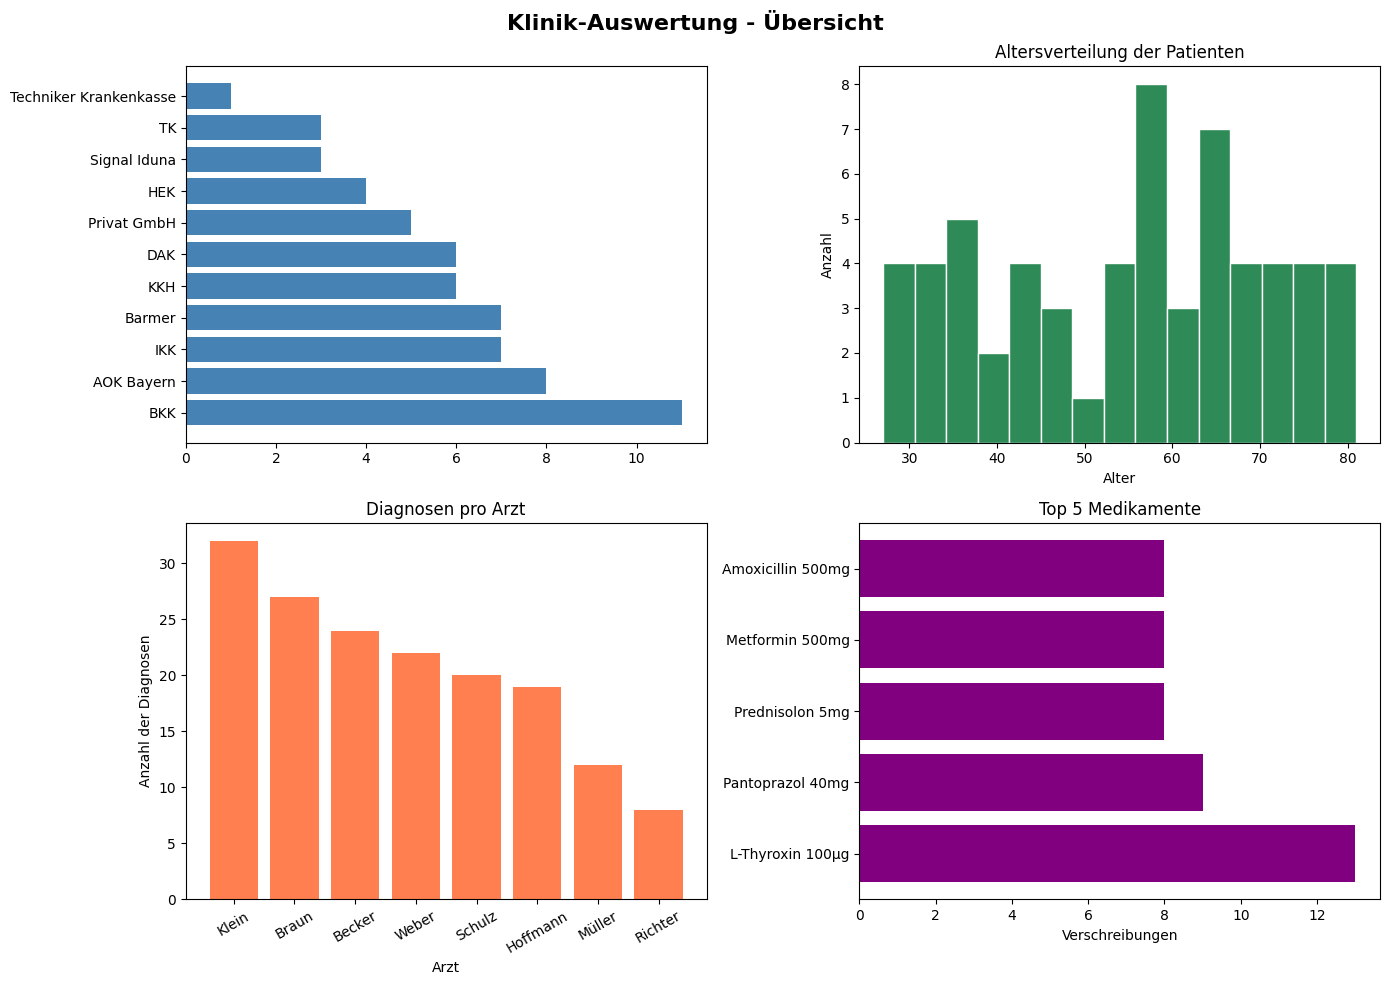

Diagramm gespeichert: klinik_uebersicht.png!


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Klinik-Auswertung - Übersicht', fontsize = 16, fontweight='bold')

#Diagramm 1: Patienten nach Versicherung (Balken)
ax1 = axes[0,0]
ax1.barh(
    versicherung_stats['versicherung'],
    versicherung_stats['anzahl'],
    color='steelblue'
)

#  Diagramm 2: Altersverteilung (Histogramm)

ax2 = axes[0,1]
ax2.hist(df_patienten['alter'], bins=15, color ='seagreen', edgecolor ='white')
ax2.set_title('Altersverteilung der Patienten')
ax2.set_xlabel('Alter')
ax2.set_ylabel('Anzahl')

#Diagramm 3: Diagnosen pro Arzt (Balken)
ax3 = axes[1,0]
ax3.bar(
    [name.split()[-1] for name in arzt_stats['arzt']],   #nur Nachname
    arzt_stats['diagnosen_gesamt'],
    color='coral'
)
ax3.set_title('Diagnosen pro Arzt')
ax3.set_xlabel('Arzt')
ax3.set_ylabel('Anzahl der Diagnosen')
ax3.tick_params(axis ='x', rotation= 30)

#Diagramm 4: Top 5 Medikamente (Balken horizontal)

ax4 = axes[1,1]
top5 = medi_stats.head(5)
ax4.barh(top5['medikament'], top5['verschreibungen'], color='purple')
ax4.set_title('Top 5 Medikamente')
ax4.set_xlabel('Verschreibungen')


plt.tight_layout()
plt.savefig('klinik_uebersicht.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagramm gespeichert: klinik_uebersicht.png!')

-----

## Block 6: Formatierten Excel Bericht erstellen

`openpyxl` ermöglicht es uns, dass wir Excel-Dateien mit Formatierung, Farben und Diagrammen erstellen können. Funktioniert vollständig automatisch, kein Geklcike durch Excel.

In [52]:
from openpyxl import Workbook
from openpyxl.styles import (
    Font, PatternFill, Alignment, Border, Side, numbers
)
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, Reference
from datetime import datetime

# Farben definieren
DUNKELBLAU  = '1C3557'
HELLBLAU    = 'EBF4FB'
WEISS       = 'FFFFFF'
GRAU        = 'F5F5F5'

def kopfzeile_formatieren(ws, zeile_nr, farbe=DUNKELBLAU):
    """Formatiert eine Kopfzeile in der angegebenen Farbe."""
    for cell in ws[zeile_nr]:
        cell.font    = Font(bold=True, color=WEISS, size=11)
        cell.fill    = PatternFill('solid', fgColor=farbe)
        cell.alignment = Alignment(horizontal='center', vertical='center')

def spaltenbreite_anpassen(ws):
    """Passe alle Spaltenbreiten autoamtisch an den Inhalt an."""
    for col in ws.columns:
        max_len = max(
            len(str(cell.value or '')) for cell in col
        )
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 45)

print("Hilfsfunktionen definiert.")

Hilfsfunktionen definiert.


In [67]:
#Excel Workbook definieren:
wb = Workbook()

#1. Tabellenblatt: Zusammenfassung
ws1 = wb.active
ws1.title = 'Zusammenfassung'

# Titel:
ws1['A1'] ='Klinik-Auswertung'
ws1['A1'].font = Font(bold=True, size = 16, color=DUNKELBLAU)
ws1['A2'] = f'Erstellt am: {datetime.now().strftime('%d.%m.%Y %H.%M')}'
ws1['A2'].font = Font(size=10, color='888888')

#KPI-Karten:
ws1['A4'] = 'Kennzahl'
ws1['B4'] = 'Wert'
kopfzeile_formatieren(ws1, 4)

kpis = [
    ('Patienten gesamt', len(df_patienten)),
    ('Diagnosen gesamt', len(df_diagnosen)),
    ('Medikamente gesamt', len(df_medikamente)),
    ('Durchschnittsalter', f'{df_patienten['alter'].mean():.1f} Jahre'),
    ('Jüngster Patient',    f'{df_patienten['alter'].min()} Jahre'),
    ('Ältester Patient',     f'{df_patienten['alter'].max()} Jahre'),
    ('Vertrauliche Diagnosen', int(df_diagnosen['vertraulich'].sum())),
    ('Behandelnde Ärzte', df_diagnosen['arzt'].nunique()),
]

for i, (name, wert) in enumerate(kpis, start=5):
    ws1[f'A{i}'] = name
    ws1[f'B{i}'] = wert
    if i % 2 == 0:
        for col in ['A', 'B']:
            ws1[f'{col}{i}'].fill = PatternFill('solid', fgColor=HELLBLAU)

spaltenbreite_anpassen(ws1)

# Tabellenblatt 2: Versicherungsauswertung

ws2 = wb.create_sheet('Versicherungen')
ws2['A1'] = 'Patienten nach Versicherung'
ws2['A1'].font = Font(bold=True, size=13, color=DUNKELBLAU)

#Daten einfügen:
headers = ['Versicherung', 'Anzahl der Patienten', 'Anteil %']
ws2.append([])   #Leerzeile
ws2.append(headers)
kopfzeile_formatieren(ws2, ws2.max_row)

for _, row in versicherung_stats.iterrows():
    ws2.append([row['versicherung'], row['anzahl'], row['anteil_pct']])
    
#Balkendiagramm hinzufügen:
chart = BarChart()
chart.title = 'Patienten nach Versicherung'
chart.style = 10
chart.height = 12
chart.width = 18

data = Reference(ws2, min_col=2, min_row=3, max_row=ws2.max_row)
labels = Reference(ws2, min_col=1, min_row=4, max_row=ws2.max_row)
chart.add_data(data, titles_from_data=True)
chart.set_categories(labels)
ws2.add_chart(chart, 'E3')

spaltenbreite_anpassen(ws2)

# 3. Diagnosen
ws3 = wb.create_sheet('Häufige Diagnosen')
ws3['A1'] = 'Top 1 häufigste Diagnosen'
ws3['A1'].font = Font(bold=True, size=13, color=DUNKELBLAU)
ws3.append([])
ws3.append(['ICD-Code', 'Beschreibung', 'Anzahl'])
kopfzeile_formatieren(ws3, ws3.max_row)

for _, row in diagnosen_stats.iterrows():
    ws3.append([row['icd_code'], row['beschreibung'], row['anzahl']])

spaltenbreite_anpassen(ws3)

#4. Ärzte:

ws4 = wb.create_sheet('Ärzte Auswertung')
ws4['A1'] = 'Diagnosen pro Arzt'
ws4['A1'].font = Font(bold=True, size=13, color= DUNKELBLAU)
ws4.append([])
ws4.append(['Arzt', 'Fachgebiet', 'Diagnosen gesamt', 'davon vertraulich'])
kopfzeile_formatieren(ws4, ws4.max_row)

for _, row in arzt_stats.iterrows():
    ws4.append([
        row['arzt'], row['fachgebiet'],
        int(row['diagnosen_gesamt']), int(row['vertraulich'])
    ])

spaltenbreite_anpassen(ws4)


#5. Rohdaten
ws5 = wb.create_sheet('Patienten Rohdaten')
ws5['A1'] = 'Alle Patienten'
ws5['A1'].font = Font(bold=True, size = 13, color = DUNKELBLAU)
ws5.append([])

export_cols = ['vorname', 'nachname', 'alter', 'altersgruppe', 'versicherung', 'arzt', 'fachgebiet']
df_export = df_patienten[export_cols].copy()
df_export['altersgruppe'] = df_export['altersgruppe'].astype(str)

rows = list(dataframe_to_rows(df_export, index=False, header=True))
for i, row in enumerate(rows):
    ws5.append(row)
    if i == 0:
        kopfzeile_formatieren(ws5, ws5.max_row)

spaltenbreite_anpassen(ws5)

dateiname = f'klinik_bericht_{datetime.now().strftime("%Y%m%d_%H%M")}.xlsx'
wb.save(dateiname)

-----

## Block 7: Bericht automatisieren

Jetzt kapseln wir alles was wir jetzt gemacht haben in eine Funktion, die man wöchentlich aufrufen kann.

In [69]:
import logging
from datetime import datetime

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger('klinik_bericht')

def klinik_bericht_erstellen(verbindung, ausgabe_pfad = "."):
    logger.info('Berichterstellung gestartet.')

    try:
        #Daten laden
        conn = psycopg2.connect(**verbindung)
        logger.info('Datenverbindung hergestellt')

        df_pat = pd.read_sql('SELECT * FROM patientendaten.patienten', conn, parse_dates=['geburtsdatum', 'aufgenommen'])
        df_diag = pd.read_sql('SELECT * FROM patientendaten.diagnosen', conn)
        df_medi = pd.read_sql('SELECT * FROM patientendaten.medikamente', conn)
        conn.close()

        logger.info(f'Daten geladen: {len(df_pat)} Patienten, ' f'{len(df_diag)} Diagnosen, {len(df_medi)} Medikamente')

        #Dateinamen mit Zeitstempel
        zeitstempel = datetime.now().strftime('%Y%m%d_%H%M')
        dateiname = f'{ausgabe_pfad}/klinik_bericht_{zeitstempel}.xlsx'

        #Excel erstellen (vereinfachte Version):
        with pd.ExcelWriter(dateiname, engine='openpyxl') as writer:
            df_pat.to_excel(writer, sheet_name='Patienten', index = False)
            df_diag.to_excel(writer, sheet_name='Diagnosen', index =False)
            df_medi.to_excel(writer, sheet_name='Medikamente', index =False)

        logger.info(f'Bericht gespeichert: {dateiname}')
        return dateiname

    except psycopg2.OperationalError as e:
        logger.error(f'Datenbankfehler: {e}')
        raise
    except Exception as e:
        logger.error(f'Fehler beim Erstellen: {type(e).__name__}: {e}')

#Bericht erstellen:
datei = klinik_bericht_erstellen(VERBINDUNG)
print(f'Heute: {datei}')

2026-05-04 12:27:05 | INFO | Berichterstellung gestartet.
2026-05-04 12:27:05 | INFO | Datenverbindung hergestellt
2026-05-04 12:27:05 | INFO | Daten geladen: 61 Patienten, 164 Diagnosen, 102 Medikamente
2026-05-04 12:27:05 | INFO | Bericht gespeichert: ./klinik_bericht_20260504_1227.xlsx


Heute: ./klinik_bericht_20260504_1227.xlsx


-----

## Block 8: Daten zurück in PostgreSQL schreiben

Ergebnisse aus einer Analyse können auch direkt wieder in die Datenbank zurückgeschrieben werden, damit andere ABteilungen sie per SQL oder über eine Maske abfragen können.

In [73]:
# AUswertungstabelle in PostgreSQL anlegen und befüllen

import psycopg2

TABELLE_SQL = '''
    CREATE TABLE IF NOT EXISTS personal.auswertung_versicherungen(
        id   SERIAL PRIMARY KEY,
        erstellt_am TIMESTAMP DEFAULT NOW(),
        versicherung TEXT NOT NULL,
        anzahl_patienten INTEGER,
        anteil_prozent NUMERIC(5,2)
    );
'''

try:
    with psycopg2.connect(**VERBINDUNG) as conn:
        with conn.cursor() as cur:
            #Tabelle anlegen:
            cur.execute(TABELLE_SQL)

            #Vorherige Ergebnisse löschen:
            cur.execute('TRUNCATE personal.auswertung_versicherungen;')

            #Neue Ergebnisse einfüttern:
            for _, row in versicherung_stats.iterrows():
                cur.execute(
                    '''
                    INSERT INTO personal.auswertung_versicherungen
                        (versicherung, anzahl_patienten, anteil_prozent)
                    VALUES (%s, %s, %s)
                    ''',
                    (row['versicherung'], int(row['anzahl']), float(row['anteil_pct']))
                )

    print('Auswertung in Datenbank gespeichert!')

except Exception as e:
    print(f' Fehler: {e}')

Auswertung in Datenbank gespeichert!
